# A labeled training set for one macroimage

This example generates five independent Q2237+0305 image-B realizations with the validated dynamic IPM preset. It uses $N=10^7$, $k=2$, $r=2$, $v=4$, the Taylor far-field approximation, frame-zero $k=1\rightarrow2$ scout normalization, temporal batch 40, and ten-frame endpoint-union scout refreshes. Each realization changes the stellar field and intrinsic broken-PSD driver while retaining the same macroimage and disk parameters.

Fluxes are physical Jy from the disk model and are plotted as AB magnitudes, $m_{\rm AB}=-2.5\log_{10}(f_\nu/3631\,\mathrm{Jy})$. Each row shows both the microlensing-only light curve and the same realization with intrinsic variability. The intrinsic source is evaluated daily while the expensive dynamic maps and source-center labels are evaluated every 25 days. Daily flux uses the two bracketing map--source contractions, so daily maps are never materialized. The three diagnostics reproduce the source-center quantities used in the paper. They are $\log_{10}\mu$, the crossing indicator, and distance to the nearest caustic. Only the center and anchor/gauge queries are evaluated. No full label map is materialized.

The first example includes any missing kernel compilation. Later examples in the same persistent GPU worker reuse those kernels. Each realization changes its star positions, stellar velocities, intrinsic driver, and random seeds without changing the source resolution, band count, temporal batch, dtype, backend, or IPM/far-field shapes. Those physical changes therefore do not require compilation per light curve. Changing a numerical shape can create one new cached specialization.

In [1]:
from pathlib import Path
import json, os, subprocess, sys
import matplotlib.pyplot as plt
import numpy as np
import torch
import microcaustics.plotting as mcp

plt.rcParams.update(mcp.publication_style())
NOTEBOOK_DIR = Path.cwd()
repository_examples = Path(mcp.__file__).resolve().parents[3] / 'examples'
local_examples = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR / 'examples'
EXAMPLES = next(path for path in (local_examples, repository_examples) if (path / 'generate_q2237_training_set.py').is_file())
OUTPUT = NOTEBOOK_DIR / 'generated' / 'q2237_b_training_set'
OUTPUT.mkdir(parents=True, exist_ok=True)
TRITON_CACHE = OUTPUT / 'triton_cache' / 'notebook'
TRITON_CACHE.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('TRITON_CACHE_DIR', str(TRITON_CACHE.resolve()))
print('CUDA:', torch.cuda.is_available(), torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'portable CPU smoke mode')

CUDA: True NVIDIA GeForce RTX 5070 Ti


In [2]:
command = [sys.executable, str(EXAMPLES / 'generate_q2237_training_set.py'), '--count', '5', '--seed', '17000', '--output-dir', str(OUTPUT), '--overwrite']
if torch.cuda.is_available():
    command += ['--gpus', '0']
else:
    command += ['--device', 'cpu', '--rays', '262144', '--source-resolution', '128', '--label-resolution', '512', '--epochs', '13']
subprocess.run(command, check=True)

CompletedProcess(args=['c:\\Users\\fagin\\miniforge3\\envs\\torch\\python.exe', 'C:\\Users\\fagin\\Desktop\\microlensing\\microcaustics_package\\examples\\generate_q2237_training_set.py', '--count', '5', '--seed', '17000', '--output-dir', 'C:\\Users\\fagin\\Desktop\\microlensing\\microcaustics_package\\examples\\notebooks\\generated\\q2237_b_training_set', '--overwrite', '--gpus', '0'], returncode=0)

first call (compile + execute)=6.451 s
warmed end-to-end LC + center labels median=4.478 s
warmed dynamic maps + center labels median=1.970 s
warmed map--source contractions median=2.457 s
warmed physical-source brightness median=0.020 s
Each row uses 147 dynamic maps/label epochs and 3,651 daily source samples.


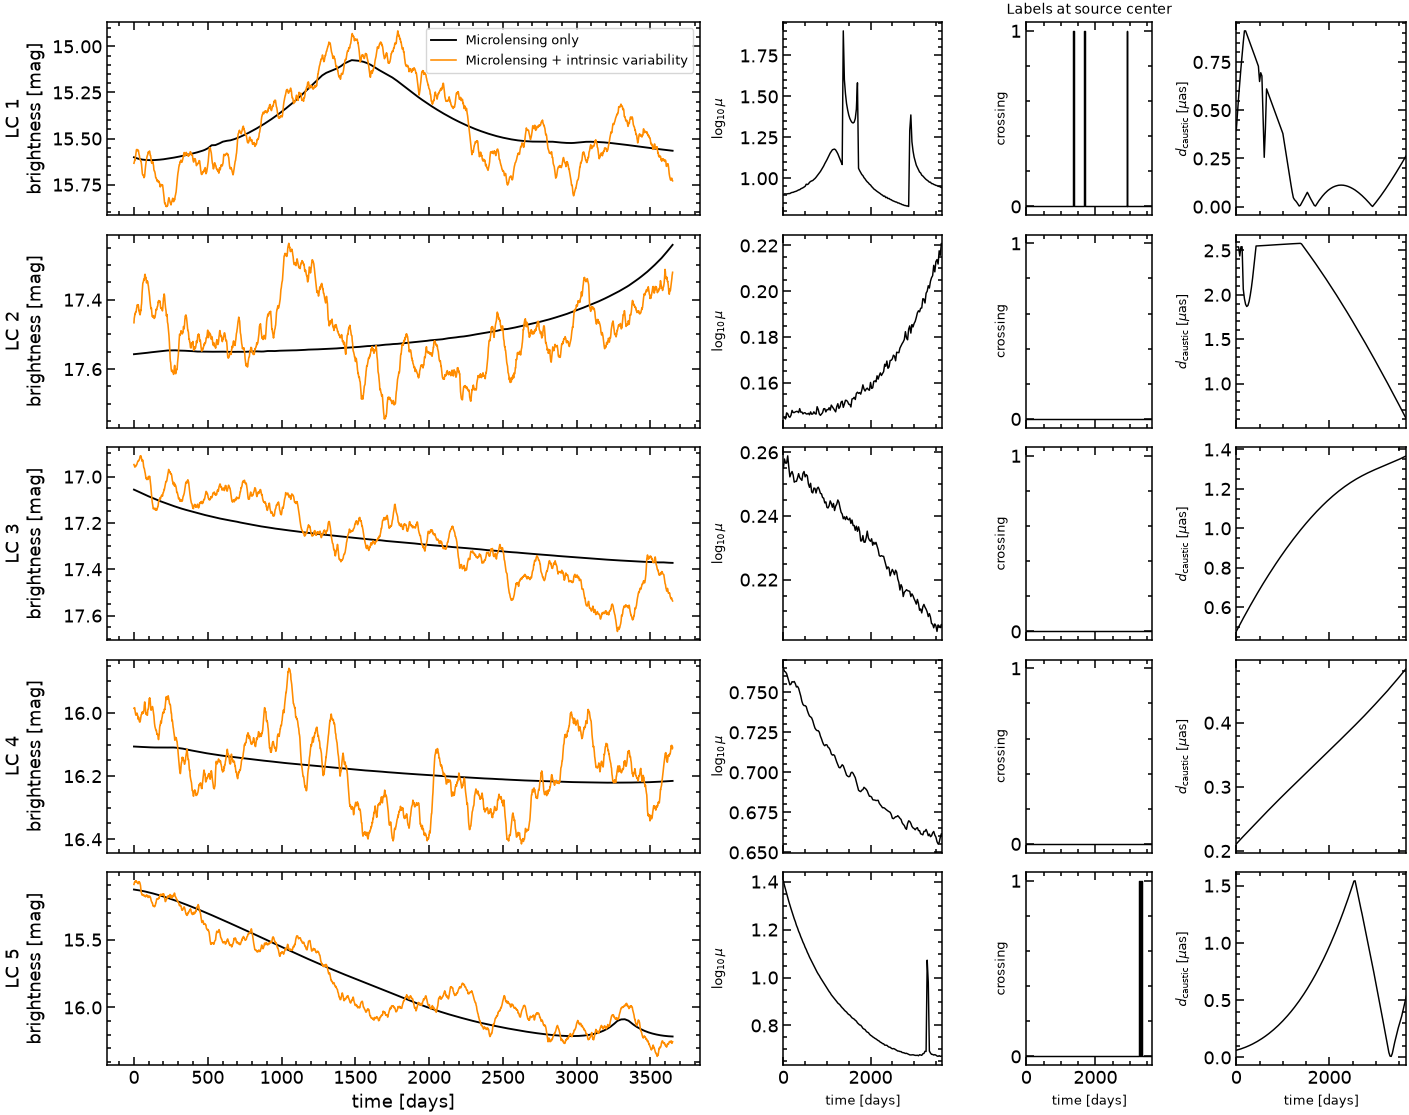

In [3]:
paths = sorted(OUTPUT.glob('light_curve_*.npz'))[:5]
metadata_rows = [json.loads(path.with_suffix('.json').read_text()) for path in paths]
runtimes = np.asarray([row['runtime_seconds'] for row in metadata_rows], dtype=float)
components = [row.get('timing_components_seconds', {}) for row in metadata_rows]
dynamic_time = np.asarray([float(component.get('dynamic_maps', np.nan)) for component in components])
source_time = np.asarray([float(component.get('source_brightness', np.nan)) for component in components])
contraction_time = np.asarray([float(component.get('map_source_contractions', np.nan)) for component in components])
print(f'first call (compile + execute)={runtimes[0]:.3f} s')
print(f'warmed end-to-end LC + center labels median={np.median(runtimes[1:]):.3f} s')
print(f'warmed dynamic maps + center labels median={np.nanmedian(dynamic_time[1:]):.3f} s')
print(f'warmed map--source contractions median={np.nanmedian(contraction_time[1:]):.3f} s')
print(f'warmed physical-source brightness median={np.nanmedian(source_time[1:]):.3f} s')
print('Each row uses 147 dynamic maps/label epochs and 3,651 daily source samples.')

records = [np.load(path) for path in paths]
fig = plt.figure(figsize=(14.2, 11.4))
layout = fig.add_gridspec(
    5, 4, width_ratios=(5.4, 1.45, 1.15, 1.55), hspace=0.10, wspace=0.32
)
for index, (record, metadata) in enumerate(zip(records, metadata_rows)):
    time = record['times_days']
    map_time = record['map_times_days'] if 'map_times_days' in record.files else time
    names = record['band_names'].astype(str).tolist()
    band = names.index('i')
    total_mag = -2.5 * np.log10(np.clip(record['flux'][:, band] / 3631.0, 1e-30, None))
    micro_mag = -2.5 * np.log10(np.clip(record['flux_microlensing_only'][:, band] / 3631.0, 1e-30, None))
    center_mu = np.log10(np.clip(record['center_magnification'], 1e-12, None))
    crossings = record['crossing_events'].astype(float)
    distance = record['center_distance_uas']

    ax = fig.add_subplot(layout[index, 0])
    ax.plot(time, micro_mag, color='black', lw=1.35, label='Microlensing only')
    ax.plot(time, total_mag, color='darkorange', lw=1.15, label='Microlensing + intrinsic variability')
    ax.invert_yaxis()
    ax.set_ylabel(f'LC {index + 1}\nbrightness [mag]')
    if index == 0:
        ax.legend(loc='upper right', frameon=True, fontsize=9)
    if index < len(records) - 1:
        ax.tick_params(labelbottom=False)
    else:
        ax.set_xlabel('time [days]')
    mcp.finish_axis(ax)

    diagnostic_values = (center_mu, crossings, distance)
    diagnostic_labels = (r'$\log_{10}\mu$', 'crossing', r'$d_{\rm caustic}$ [$\mu$as]')
    for column, (values, ylabel) in enumerate(zip(diagnostic_values, diagnostic_labels), start=1):
        label_ax = fig.add_subplot(layout[index, column])
        if column == 2:
            label_ax.step(map_time, values, where='pre', color='black', lw=1.05)
            label_ax.set_ylim(-0.05, 1.05)
            label_ax.set_yticks((0, 1))
        else:
            label_ax.plot(map_time, values, color='black', lw=1.05)
        label_ax.set_xlim(float(time[0]), float(time[-1]))
        label_ax.set_ylabel(ylabel, fontsize=9, labelpad=2)
        if index == 0 and column == 2:
            label_ax.set_title('Labels at source center', fontsize=10)
        if index < len(records) - 1:
            label_ax.tick_params(labelbottom=False)
        else:
            label_ax.set_xlabel('time [days]', fontsize=9)
        mcp.finish_axis(label_ax)

fig.align_ylabels()
fig.subplots_adjust(left=0.075, right=0.99, bottom=0.065, top=0.98)
fig.savefig(OUTPUT / 'five_q2237_b_training_curves.pdf', bbox_inches='tight')
plt.show()

## Inspect one magnification map from every realization

Training files remain compact and do not store every $1024^2$ map. The following cell deterministically reconstructs all five realizations and generates their $t=0$ maps. These visualization calls occur **after** the reported light-curve timing and are not included in it. Every panel uses the same production $N=10^7$, $k=2$, $r=2$, $v=4$ dynamic configuration and caustic extraction. A shared color scale makes the independent stellar realizations directly comparable.

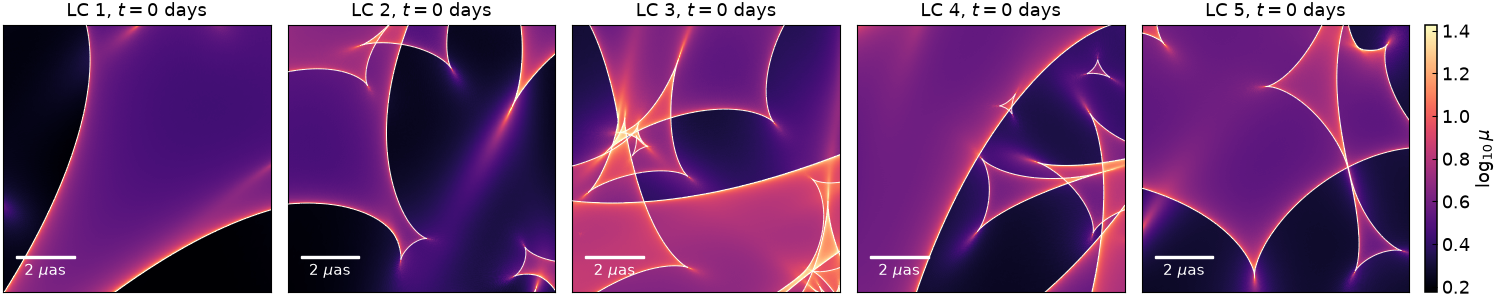

These five separate map visualizations are excluded from all light-curve timings above.


In [4]:
import microcaustics as mc
sys.path.insert(0, str(EXAMPLES)) if str(EXAMPLES) not in sys.path else None
from training_set_support import q2237_b_system

example_device = 'cuda' if torch.cuda.is_available() else 'cpu'
example_rays = 10_000_000 if torch.cuda.is_available() else 262_144
example_source_resolution = 1024 if torch.cuda.is_available() else 128
example_label_resolution = 8192 if torch.cuda.is_available() else 512
example_method = mc.production_ipm_config(dynamic=True, rays=example_rays)
example_caustics = mc.CausticConfig(
    far_field_approx=example_method.far_field_approx, temporal_batch_size=1,
    anchor_count=9, gauge_count=9, float64_label_fallback=False,
)
example_frames = []
for metadata in metadata_rows:
    training_system = q2237_b_system(
        seed=int(metadata['seed']), driver_seed=int(metadata['driver_seed']),
        device=example_device, times_days=torch.tensor([0.0, 1.0]),
        source_resolution=example_source_resolution,
        label_resolution=example_label_resolution,
    )
    frame = next(iter(training_system.simulation.dynamic_labeled_maps(
        training_system.lens_region, training_system.source_grid, training_system.lens_grid, [0.0],
        method=example_method, map_schedule=mc.production_dynamic_config(),
        caustic_config=example_caustics,
    )))
    example_frames.append(frame)

log_maps = [np.log10(np.clip(frame.magnification_map.values.detach().cpu().numpy(), 1e-12, None)) for frame in example_frames]
all_finite = np.concatenate([value[np.isfinite(value)] for value in log_maps])
vmin, vmax = np.percentile(all_finite, (0.25, 99.75))
figure = plt.figure(figsize=(14.8, 3.15))
layout = figure.add_gridspec(1, 6, width_ratios=(1, 1, 1, 1, 1, 0.045), wspace=0.06)
axes = [figure.add_subplot(layout[0, index]) for index in range(5)]
colorbar_ax = figure.add_subplot(layout[0, 5])
for index, (ax, frame) in enumerate(zip(axes, example_frames)):
    mcp.plot_magnification_map(
        frame.magnification_map, ax=ax, caustics=frame.caustics.caustics,
        log10=True, vmin=float(vmin), vmax=float(vmax), colorbar=False,
        scale_bar_uas=2.0, show_axes=False,
        title=rf'LC {index + 1}, $t=0$ days',
    )
colorbar = figure.colorbar(axes[-1].images[-1], cax=colorbar_ax)
colorbar.set_label(r'$\log_{10}\mu$')
colorbar.ax.tick_params(direction='in')
figure.subplots_adjust(left=0.015, right=0.985, bottom=0.03, top=0.88)
figure.savefig(OUTPUT / 'five_q2237_b_maps.pdf', bbox_inches='tight')
plt.show()
print('These five separate map visualizations are excluded from all light-curve timings above.')

For a larger set or several GPUs, use `python examples/generate_q2237_training_set.py --count 1000 --gpus 0 1 2 3`. One persistent worker is pinned to each GPU. Files already completed are reused after interruption.